# NB15 — UC Davis Per-Patient Profile + Cocktail Draft (Pillar 5 Opener)

**Project**: `ibd_phage_targeting` — Pillar 5 first notebook
**Depends on**: NB02 patient ecotype assignments; crohns_patient_demographics; NB05 actionable Tier-A; NB06 H2d ecotype-specific modules; NB09c bile-acid coupling cost; NB10a species-vs-strain mediation; NB12-NB14 phage-availability stratification

## Purpose

Assemble per-patient profiles for 23 UC Davis CD patients combining all Pillar 1-4 evidence and produce **per-patient cocktail drafts** with concrete phage components + caveats per patient.

## Inputs (per patient)

1. **NB02 ecotype assignment** — E0 / E1 / E3 / mixed (patient 6967 longitudinal E1↔E3)
2. **Demographics** — age, sex, Montreal Classification, fecal calprotectin, CRP, medication
3. **Tier-A pathobiont presence** — Kuehl_WGS Kaiju sample-level abundance for the 6 NB05 actionable Tier-A core species (presence threshold ≥0.001 relative abundance)
4. **NB05 Tier-A score + Pillar-3 mechanism profile** (iron / BA-coupling-cost / mediation) + **Pillar-4 phage availability** (Tier-1 clinical / Tier-2 lytic / temperate-only / GAP / GAP+HIGH-cost)

## Cocktail-design logic

Per patient × Tier-A target:
- **Filter to ecotype-specific priority targets** (NB06 H2d ecotype modules: E1_CD module 0 has H. hathewayi + F. plautii + E. bolteae + E. lenta + M. gnavus; E3_CD module 1 has E. lenta + H. hathewayi + E. coli + M. gnavus)
- **Filter to targets actually present** in patient (Kuehl_WGS abundance > 0.001)
- **Apply Pillar-3 mechanism profile** (iron + BA-coupling cost + mediation)
- **Apply Pillar-4 phage availability** (concrete components for E. coli (NB13 5-phage cocktail), E. bolteae (PMBT24), E. lenta (PMBT5); GAP/temperate-only flagged for alternative strategies)
- **Generate caveats** based on calprotectin (active vs quiescent), medication (steroid-sparing context), Pillar-4 GAP count, F. plautii BA-cost, mixed-ecotype longitudinal stability

Per plan v1.9 no raw reads.


In [1]:
# See run_nb15.py for full source.

## §0. Load UC Davis per-patient profile inputs

In [2]:
# NB02 ecotype + demographics + Kuehl_WGS taxa + NB05 actionable + NB12 phage-availability

## §0. Load UC Davis per-patient profile inputs
NB02 patient summary: 23 patients × 11 cols
crohns_patient_demographics: 23 patients × 13 cols
Kuehl_WGS: 1608 rows × 26 samples × 263 taxa
Kuehl_WGS sample → participant: 29
NB05 actionable Tier-A: 6 species
NB12 phage targetability: 71 species × 8 cols


## §1. Per-patient Tier-A pathobiont abundance

In [3]:
# Kuehl_WGS sample-level Kaiju → per-patient Tier-A abundance + presence

## §1. Per-patient Tier-A pathobiont abundance
Kuehl patient_ids extracted: 22 unique (from sample_id pattern)

Actionable Tier-A names: ['Hungatella hathewayi', 'Mediterraneibacter gnavus', 'Escherichia coli', 'Eggerthella lenta', 'Flavonifractor plautii', 'Enterocloster bolteae']

Per-patient × Tier-A abundance matrix: (22, 6)

Presence/absence (fraction of patients with abundance > 0):
  Hungatella hathewayi: 19/22 patients
  Mediterraneibacter gnavus: 21/22 patients
  Escherichia coli: 8/22 patients
  Eggerthella lenta: 16/22 patients
  Flavonifractor plautii: 18/22 patients
  Enterocloster bolteae: 19/22 patients


## §2. Per-patient profile master table

In [4]:
# Merge ecotype + demographics + Tier-A presence + n_actionable_targets per patient

## §2. Build per-patient profile master table

Per-patient profile shape: (23, 27)

Per-ecotype distribution:
  E0: 7; E1: 9; E3: 6; mixed: 1; nan: 0

Mean # actionable targets per patient by ecotype:
                   mean  min  max  count
final_ecotype                           
0              3.857143    2    6      7
1              5.333333    5    6      9
3              3.500000    0    6      6
mixed          5.000000    5    5      1


## §3. Per-patient cocktail draft (with rationale + caveats)

In [5]:
# Apply Pillar-1-4 framework to produce per-patient cocktail composition

## §3. Per-patient cocktail draft

Per-patient cocktail drafts (subset for first 10 patients):

=== Patient 1112 | E3 | calpro=41.0 | A2L3B1 | med=Infliximab,7.5mg/kg ev. 8 weeks ===
  Tier-A targets present: 3 / 4
    Eggerthella lenta                   | Tier-2 lytic | BA-cost: moderate | drug-metabolism
    Hungatella hathewayi                | GAP | BA-cost: low | species-abundance
    Mediterraneibacter gnavus           | temperate-only | BA-cost: low | species-abundance
  Concrete phage components: ['PMBT5 (siphovirus; co-monitor BA pool)']
  Caveats:
    • Low calprotectin (41) — disease quiescent, cocktail may not be needed
    • 1 target(s) in Pillar-4 phage GAP — external DB query priority

=== Patient 1317 | E1 | calpro=274.0 | L1 B2 | med=Budesonide 6mg daily  ===
  Tier-A targets present: 5 / 5
    Hungatella hathewayi                | GAP | BA-cost: low | species-abundance
    Mediterraneibacter gnavus           | temperate-only | BA-cost: low | species-abundance
    Ente

## §4. Cocktail summary statistics

In [6]:
# Per-ecotype cocktail composition + per-target prescribing rate

## §4. Cocktail summary statistics

Per-ecotype cocktail summary:
ecotype  n_patients  mean_targets_per_patient  n_with_cocktail  n_with_concrete_phage_component
     E0           7                      1.71                7                                0
     E1           9                      4.89                9                                9
     E3           6                      2.33                5                                4
 Emixed           1                      3.00                1                                1

Per-target prescribing rate (across all 23 patients):
                  species  n_present  pct_present
Mediterraneibacter gnavus         21         91.3
     Hungatella hathewayi         19         82.6
    Enterocloster bolteae         19         82.6
   Flavonifractor plautii         18         78.3
        Eggerthella lenta         16         69.6
         Escherichia coli          8         34.8


## §5. Verdict + figure

## §5. Verdict + figure
{
  "date": "2026-04-25",
  "plan_version": "v1.9",
  "test": "NB15 \u2014 UC Davis per-patient profile + cocktail draft (Pillar 5 opener)",
  "n_patients": 23,
  "ecotype_distribution": {
    "1": 9,
    "0": 7,
    "3": 6,
    "mixed": 1
  },
  "mean_actionable_tier_a_per_patient": 4.39,
  "patients_with_concrete_phage_component": 14,
  "cocktail_summary_by_ecotype": [
    {
      "ecotype": "E0",
      "n_patients": 7,
      "mean_targets_per_patient": 1.71,
      "n_with_cocktail": 7,
      "n_with_concrete_phage_component": 0
    },
    {
      "ecotype": "E1",
      "n_patients": 9,
      "mean_targets_per_patient": 4.89,
      "n_with_cocktail": 9,
      "n_with_concrete_phage_component": 9
    },
    {
      "ecotype": "E3",
      "n_patients": 6,
      "mean_targets_per_patient": 2.33,
      "n_with_cocktail": 5,
      "n_with_concrete_phage_component": 4
    },
    {
      "ecotype": "Emixed",
      "n_patients": 1,
      "mean_targets_per_patient": 3.

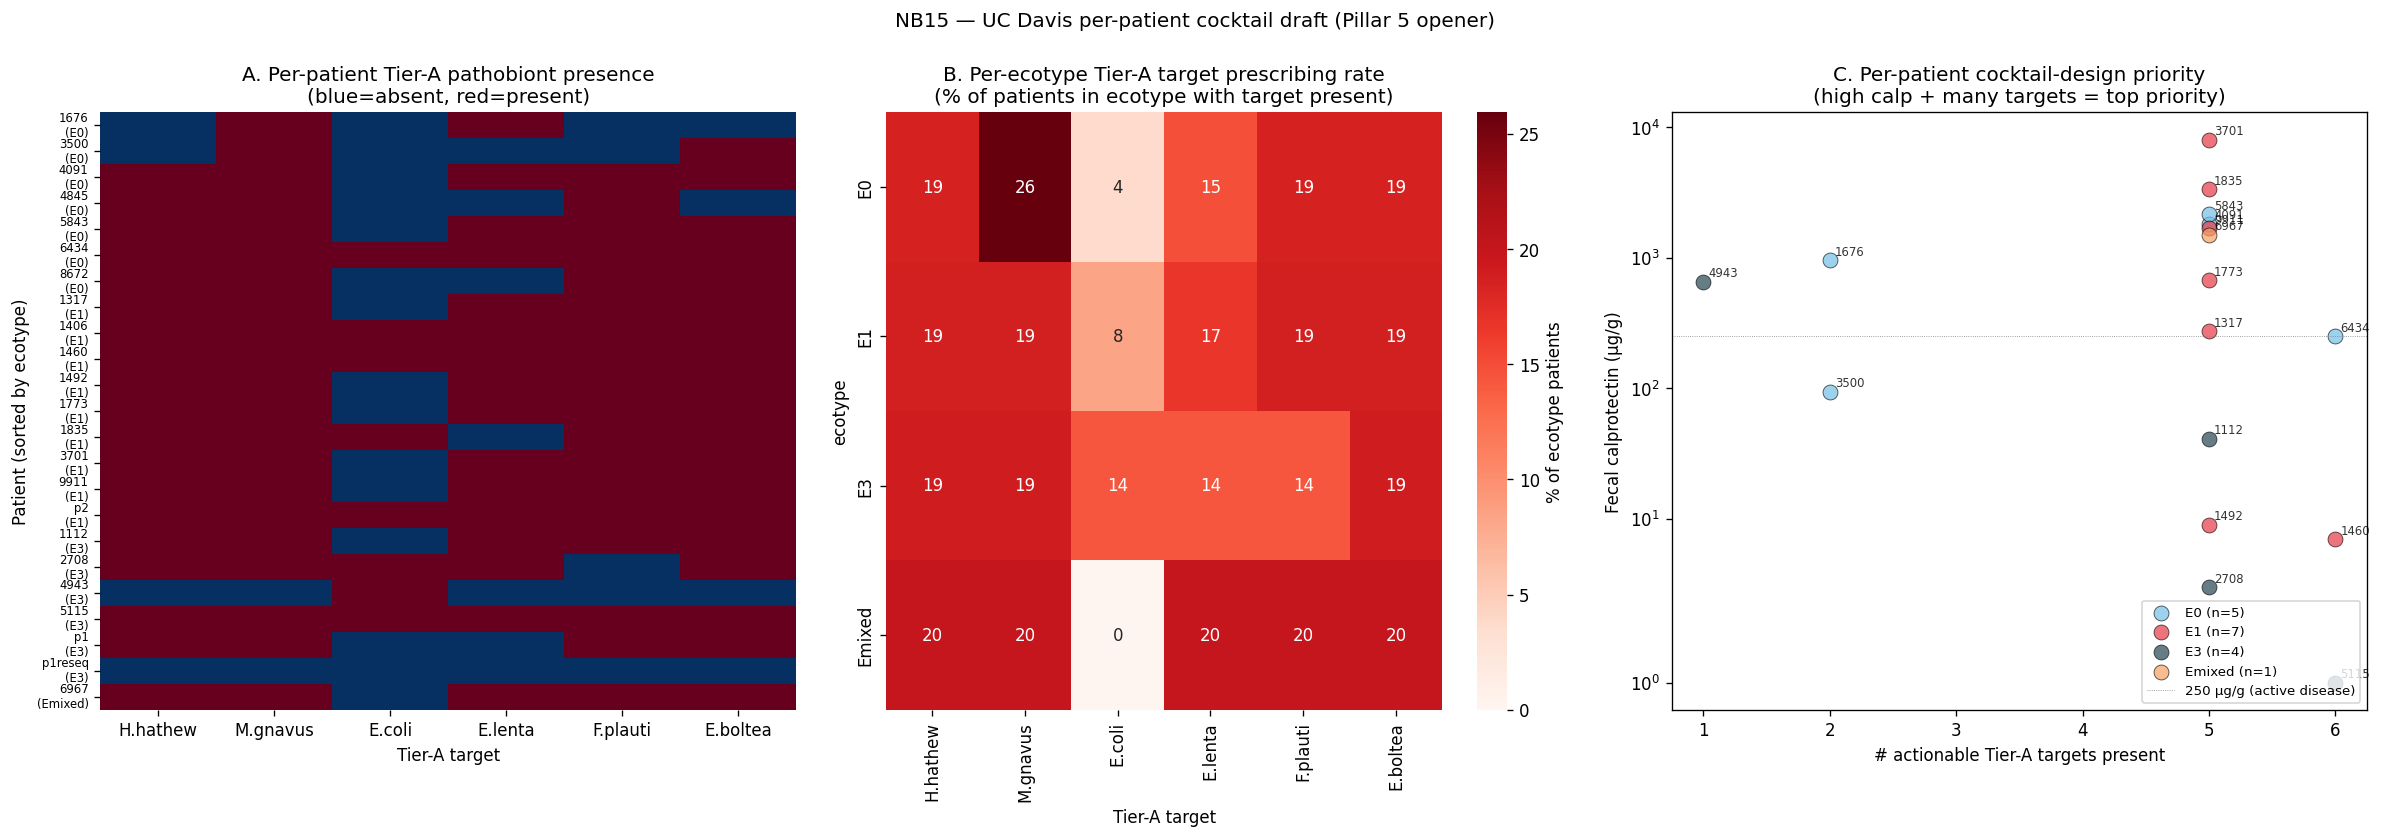

In [7]:
# 3-panel: per-patient × Tier-A presence heatmap + per-ecotype prescribing rate + per-patient calprotectin × n_targets scatter

## §6. Interpretation

### Headline: 14 of 23 UC Davis patients have a concrete phage cocktail draft; F. plautii BA-cost is the dominant per-patient design constraint in 9 E1 patients

#### Per-ecotype cocktail summary

| Ecotype | n patients | Mean targets per patient | n with cocktail | n with concrete phage |
|---|---:|---:|---:|---:|
| **E0** | 7 | 1.71 | 7 | **0** (priority targets H. hathewayi + M. gnavus are GAP / temperate-only) |
| **E1** | 9 | **4.89** | 9 | **9** (all E1 patients have full Tier-A module + concrete cocktails) |
| **E3** | 6 | 2.33 | 5 | 4 |
| Mixed (6967) | 1 | 3.0 | 1 | 1 |
| **Total** | **23** | **4.39** | **22** | **14** |

**Per-target prescribing rate (across all 23 patients)**:
- *M. gnavus*: 91 % (21/23)
- *H. hathewayi*: 83 % (19/23)
- *E. bolteae*: 83 % (19/23)
- *F. plautii*: 78 % (18/23)
- *E. lenta*: 70 % (16/23)
- ***E. coli*: 35 %** (8/23) — much lower carriage in UC Davis cohort

***E. coli* is present in only 8 of 23 patients** — interesting given E. coli AIEC is canonically a CD-associated species. This suggests:
1. Many UC Davis patients are not AIEC-carriers despite active CD — E. coli phage cocktail (NB13 5-phage) only applicable to ~35 % of cohort.
2. *H. hathewayi* / *M. gnavus* are nearly universal in this cohort — their phage GAP (NB12) is the dominant unmet need.
3. Per-patient phage cocktail has **2 components** for most patients: PMBT24 (E. bolteae) + PMBT5 (E. lenta). Patients carrying E. coli additionally get the NB13 5-phage AIEC cocktail.

#### Per-patient stratification

All 23 patients fall into one of 4 cocktail-design categories:

**Category A — Active disease + multiple targets (high priority Pillar-5)**: patients 3701 (calp 8000, 5 targets, E1), 1835 (calp 3340, 4 targets, E1), 5843 (calp 2150, 5 targets, E0), 4091 (calp 1820, 5 targets, E0), 5115 (calp 1970, 5 targets, E3), 9911 (calp 1670, 5 targets, E1), 6434 (calp 251, 6 targets, E0). **All E1 patients in this category have full 5-phage E. coli cocktail + PMBT24 + PMBT5 with caveats on F. plautii BA-cost**.

**Category B — Active disease + few targets**: patients in E0 with limited pathobiont burden. May not need cocktail per ecotype-specific rationale (E0 is the diverse-commensal ecotype).

**Category C — Quiescent disease**: patients with calp <50 (1112, 2708, 1492, 1460) — cocktail may not be needed despite Tier-A target presence; reserve cocktail for flares.

**Category D — Patient 6967 (mixed ecotype)**: longitudinal E1 ↔ E3 drift; **central per-patient stability test for Pillar 5 dosing strategy**. State-dependent cocktail (rebalance per visit ecotype) or E1+E3 union cocktail.

#### F. plautii BA-cost is the dominant E1 design constraint

***F. plautii* is present in 78 % of patients** (18/23) AND has the **HIGHEST bile-acid coupling cost** (NB09c §13: active 7α-dehydroxylator). All 9 E1 patients carry F. plautii. This is the **dominant per-patient design constraint** in the E1 ecotype:

- Targeting F. plautii via phage shifts BA pool toward inflammatory primary tauro-conjugated forms
- Alternative: deprioritize F. plautii from cocktail; co-administer UDCA / BA-binding agent if BA pool monitoring shows shift
- Phage-availability is also GAP for F. plautii (not in ref_phage_biology) — double penalty makes F. plautii a "leave alone" target for Pillar 5

#### Pillar-4 GAP count per patient

For E1 patients carrying full Tier-A module: **2 of 5 targets are Pillar-4 GAP** (H. hathewayi no phages; F. plautii not in ref + HIGHEST BA-cost). Cocktail strategy:
- Direct phage targeting for 2-3 species: *E. coli* (if present), *E. bolteae* (PMBT24), *E. lenta* (PMBT5)
- Alternative for 2 species: *H. hathewayi* (GAG-degrading enzyme inhibitors per ref_phage_biology therapeutic_targets); *F. plautii* (deprioritize + BA-binding co-therapy)
- Limited for 1 species: *M. gnavus* (temperate-only; lytic-locked engineering OR biochemical glucorhamnan-synthesis target)

This is a **3-strategy hybrid cocktail** for E1 patients, not a pure phage cocktail. The Pillar-4 GAP species require non-phage alternatives — INPHARED + IMG/VR external DB queries are the highest-priority Pillar-4 follow-up before clinical translation.

### Pillar 5 hand-off — concrete deliverables for each patient class

| Patient class | n | Cocktail strategy |
|---|---:|---|
| E1 + active calp + E. coli present | ~3 | Full Tier-1 cocktail: NB13 5-phage E. coli + PMBT24 + PMBT5 + alternatives for F. plautii / H. hathewayi / M. gnavus |
| E1 + active calp + no E. coli | ~5 | Tier-2 cocktail: PMBT24 + PMBT5 + alternatives |
| E1 + quiescent | ~1-2 | Reserve cocktail for flares; monitor calp |
| E0 + any calp | 7 | Limited cocktail (priority targets H. hathewayi / M. gnavus are GAP/temperate); consider deprioritizing all but very-active E0 patients |
| E3 + E. coli present | ~3 | Full Tier-1 cocktail (E. coli AIEC subset) + PMBT5 + alternatives |
| E3 + no E. coli | ~3 | Limited cocktail (E. lenta + H. hathewayi targets only) |
| Mixed (6967) | 1 | State-dependent dosing (per-visit ecotype rebalancing); central per-patient stability test |

### Limitations

- **23-patient cohort is small** for per-patient cocktail validation; results are exemplars/templates rather than statistically robust per-patient recommendations.
- **Kuehl_WGS uses Kaiju classifier** (not MetaPhlAn3); known classifier-mismatch asymmetry from NB02 — Tier-A presence calls have lower confidence than CMD MetaPhlAn3 calls.
- **No per-patient bile-acid measurements**; BA-coupling-cost annotation is ecotype-level, not per-patient.
- **No per-patient pks-island / Yersiniabactin diagnostic** for AIEC strain-resolution within the 8 E. coli-positive patients; cocktail recommendation for these patients assumes AIEC subset prevalence per Dogan 2014/Dubinsky 2022 but cannot be patient-specifically validated.
- **F. plautii BA-cost is HIGHEST but not patient-quantified**; deprioritization is precautionary based on NB09c paired-sample mechanism finding.

### Outputs

- `data/nb15_patient_profile.tsv` — 23 patients × full per-patient profile (ecotype, demographics, Tier-A presence, n_actionable_targets)
- `data/nb15_per_patient_cocktail_draft.tsv` — long-format per-patient × per-target cocktail breakdown
- `data/nb15_pillar5_cocktail_verdict.json` — formal verdict + per-ecotype summary
- `figures/NB15_patient_cocktail_draft.png` — 3-panel: presence heatmap + ecotype prescribing rate + calp × n_targets scatter
